<a href="https://colab.research.google.com/github/scardenol/Stochastic_Optimization_2026/blob/main/%22Pr%C3%A1ctica%201%22/practica1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cargar liberías

In [1]:
import urllib.request # para leer datos desde una url
import polars as pl
from datetime import datetime, time # para filtrar los datos

# Cargar datos

In [2]:
# Link textual para descargar el archivo
url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2015-01.parquet"
local_file = "yellow_tripdata_2015-01.parquet" # Nombre del archivo

# Descargar el archivo local (o en la sesión de Colab)
urllib.request.urlretrieve(url, local_file)

# Leer el archivo
df = pl.read_parquet(local_file)

In [3]:
# Visualizar
df.head()

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
i64,datetime[ns],datetime[ns],i64,f64,i64,str,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,null,null
1,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,"""N""",41,166,1,5.7,0.5,0.5,1.4,0.0,0.0,8.4,null,null
1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,"""N""",166,238,3,6.0,0.5,0.5,0.0,0.0,0.0,7.3,null,null
1,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,"""N""",238,162,1,13.2,0.5,0.5,2.9,0.0,0.0,17.4,null,null
1,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,"""N""",162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,null,null
1,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,"""N""",236,141,3,6.0,0.5,0.5,0.0,0.0,0.0,7.3,null,null


In [4]:
# Dimensiones (filas, columnas)
df.shape

(12741035, 19)

In [5]:
# Tamaño estimado en MB
df.estimated_size("mb")

1567.4648818969727

In [6]:
# Columnas y tipos
df.schema

Schema([('VendorID', Int64),
        ('tpep_pickup_datetime', Datetime(time_unit='ns', time_zone=None)),
        ('tpep_dropoff_datetime', Datetime(time_unit='ns', time_zone=None)),
        ('passenger_count', Int64),
        ('trip_distance', Float64),
        ('RatecodeID', Int64),
        ('store_and_fwd_flag', String),
        ('PULocationID', Int64),
        ('DOLocationID', Int64),
        ('payment_type', Int64),
        ('fare_amount', Float64),
        ('extra', Float64),
        ('mta_tax', Float64),
        ('tip_amount', Float64),
        ('tolls_amount', Float64),
        ('improvement_surcharge', Float64),
        ('total_amount', Float64),
        ('congestion_surcharge', Null),
        ('airport_fee', Null)])

In [7]:
# Extraer columnas relevantes
datos = df.select(["tpep_pickup_datetime",
                   "tpep_dropoff_datetime",
                   "PULocationID",
                   "DOLocationID",
                   "trip_distance"])
datos.head()

tpep_pickup_datetime,tpep_dropoff_datetime,PULocationID,DOLocationID,trip_distance
datetime[ns],datetime[ns],i64,i64,f64
2015-01-01 00:11:33,2015-01-01 00:16:48,41,166,1.0
2015-01-01 00:18:24,2015-01-01 00:24:20,166,238,0.9
2015-01-01 00:26:19,2015-01-01 00:41:06,238,162,3.5
2015-01-01 00:45:26,2015-01-01 00:53:20,162,263,2.1
2015-01-01 00:59:21,2015-01-01 01:05:24,236,141,1.0


# Filtrar datos

## 1) Registros considerados
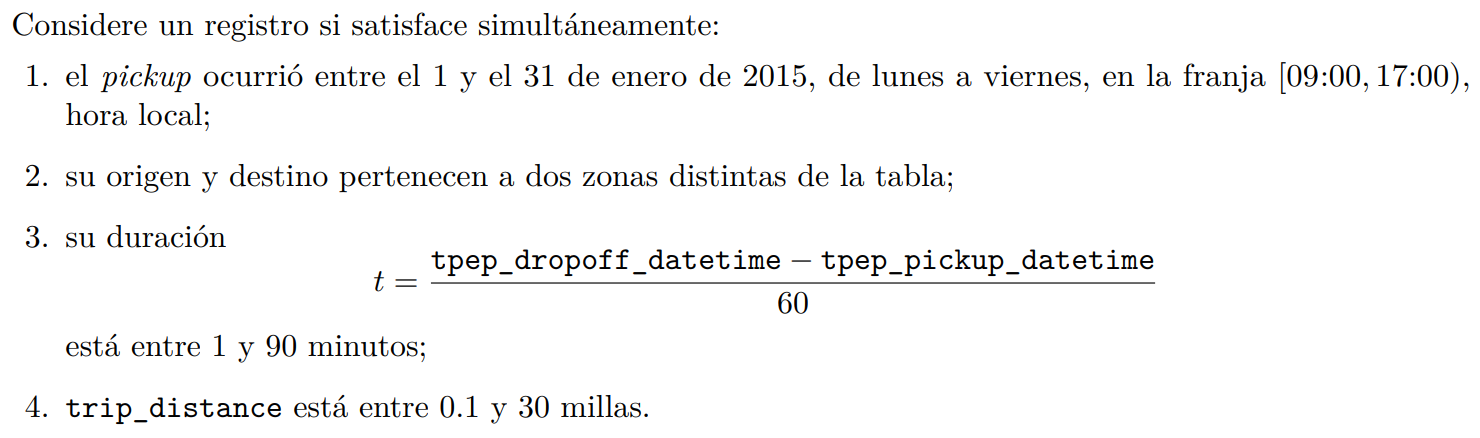

In [8]:
# 1) Filtro de pickup

# pikcup entre el 1 y el 31 de enero de 2015 (inclusivo)
datos = datos.filter(
    pl.col("tpep_pickup_datetime").is_between(datetime(2015, 1, 1), datetime(2015, 1, 31)), # 1 a 31 de enero de 2015
    pl.col("tpep_pickup_datetime").dt.weekday().is_between(1, 5), # de lunes (1) a viernes (5)
    (pl.col("tpep_pickup_datetime").dt.time() >= time(9, 0)) & (pl.col("tpep_pickup_datetime").dt.time() < time(17, 0)) # en [09:00, 17:00)
    )

In [9]:
# 2) Filtro de origen y destino

# Definir el dataframe de zonas usando la info de la tabla explícita
zonas_data = [
    (0, "Depósito: Javits Center", 40.75750, -74.00250, 246),
    (1, "Times Square", 40.75800, -73.98550, 230),
    (2, "Rockefeller Center", 40.75870, -73.97870, 161),
    (3, "Grand Central Terminal", 40.75278, -73.97722, 162),
    (4, "New York Public Library (Main)", 40.75306, -73.98194, 164),
    (5, "Union Square", 40.73590, -73.99110, 234),
    (6, "Washington Square Park", 40.73083, -73.99750, 114),
    (7, "Madison Square Garden", 40.75056, -73.99361, 186),
    (8, "One World Trade Center", 40.71274, -74.01338, 261),
    (9, "New York Stock Exchange", 40.70693, -74.01125, 87),
    (10, "South Street Seaport (Pier 17)", 40.70600, -74.00270, 209),
]

# Declaración del schema
zonas_schema = {
    "i": pl.Int64,
    "Sitio": pl.Utf8,
    "Latitud": pl.Float64,
    "Longitud": pl.Float64,
    "LocationID": pl.Int64
}

# Construir el dataframe
zonas_df = pl.DataFrame(zonas_data, schema=zonas_schema)

# Imprimir resultado
zonas_df

/tmp/ipykernel_43843/1686202698.py:28: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  zonas_df = pl.DataFrame(zonas_data, schema=zonas_schema)


i,Sitio,Latitud,Longitud,LocationID
i64,str,f64,f64,i64
0,"""Depósito: Javits Center""",40.7575,-74.0025,246
1,"""Times Square""",40.758,-73.9855,230
2,"""Rockefeller Center""",40.7587,-73.9787,161
3,"""Grand Central Terminal""",40.75278,-73.97722,162
4,"""New York Public Library (Main)""",40.75306,-73.98194,164
…,…,…,…,…
6,"""Washington Square Park""",40.73083,-73.9975,114
7,"""Madison Square Garden""",40.75056,-73.99361,186
8,"""One World Trade Center""",40.71274,-74.01338,261


In [10]:
# IDs de pickup y dropoff que estén en las zonas preseleccionadas
loc_ids = zonas_df["LocationID"].to_list()
datos = datos.filter(
    pl.col("PULocationID").is_in(loc_ids),
    pl.col("DOLocationID").is_in(loc_ids),
    pl.col("PULocationID") != pl.col("DOLocationID")  # Se excluyen viajes i=j
)

In [11]:
# 3) Duración entre 1 y 90 minutos

# Agregar la nueva columna de tiempo t=(dropoff-pickup)/60
datos = datos.with_columns(t = (pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime")).dt.total_minutes())

# Filtrar con t en [1, 90]
datos = datos.filter(pl.col("t").is_between(1, 90))

In [12]:
# 4) Distancia de viaje entre 0.1 y 30 millas

# trip_distance en [0.1, 30]
datos = datos.filter(pl.col("trip_distance").is_between(0.1, 30))

## 2) Pools y control de calidad
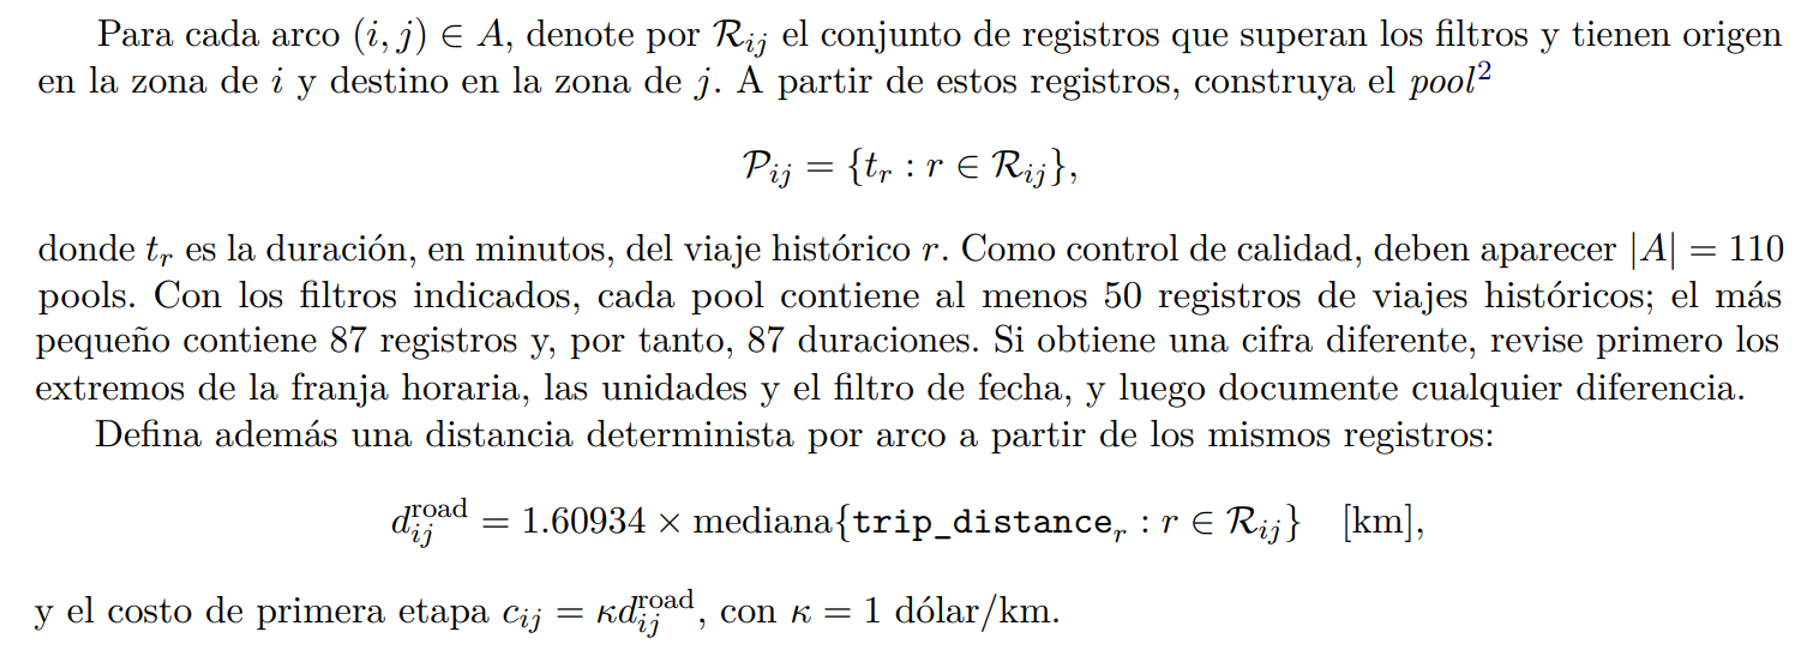

In [13]:
# Costo de desplazamiento
kappa = 1.0  # USD / km

# Construir los pools agrupando por ("PULocationID", "DOLocationID")
pools = (
    datos.group_by(["PULocationID", "DOLocationID"])
    .agg(
        # Pool P_ij (histórico de duraciones)
        pl.col("t").alias("P_ij"),

        # Tamaño de cada pool o número de registros |R_ij|
        pl.len().alias("registros"),

        # Distancia determinista por arco [km]: median(miles) * 1.60934
        (pl.col("trip_distance").median() * 1.60934).alias("d_road_ij")
    )
    # Costo de primera etapa c_ij = kappa * d_road_ij
    .with_columns(
        (kappa * pl.col("d_road_ij")).alias("c_ij")
    )
    # Mapear PULocationID -> i
    .join(
        zonas_df.select([pl.col("LocationID").alias("PULocationID"), pl.col("i")]),
        on="PULocationID"
    )
    # Mapear DOLocationID -> j
    .join(
        zonas_df.select([pl.col("LocationID").alias("DOLocationID"), pl.col("i").alias("j")]),
        on="DOLocationID"
    )
    # Seleccionar las columnas en el orden que se quiere y ordenar
    .select(["i", "j", "d_road_ij", "c_ij", "P_ij", "registros"])
    .sort(["i", "j"])
)

pools

i,j,d_road_ij,c_ij,P_ij,registros
i64,i64,f64,f64,list[i64],u32
0,1,2.253076,2.253076,"[3, 8, … 10]",3228
0,2,2.896812,2.896812,"[9, 9, … 16]",2661
0,3,3.540548,3.540548,"[8, 8, … 16]",1322
0,4,2.204796,2.204796,"[7, 6, … 13]",2165
0,5,2.236983,2.236983,"[5, 4, … 11]",3440
…,…,…,…,…,…
10,5,6.43736,6.43736,"[15, 13, … 18]",201
10,6,2.961186,2.961186,"[10, 10, … 18]",87
10,7,5.5361296,5.5361296,"[11, 12, … 23]",136


In [14]:
# Control de calidad
print(f"Número de pools: |A| = {pools.shape[0]}")
print(f"Número de registros del pool más pequeño: |P_ij| = {pools["registros"].min()}")

Número de pools: |A| = 110
Número de registros del pool más pequeño: |P_ij| = 87


# Vector aleatorio y escenarios
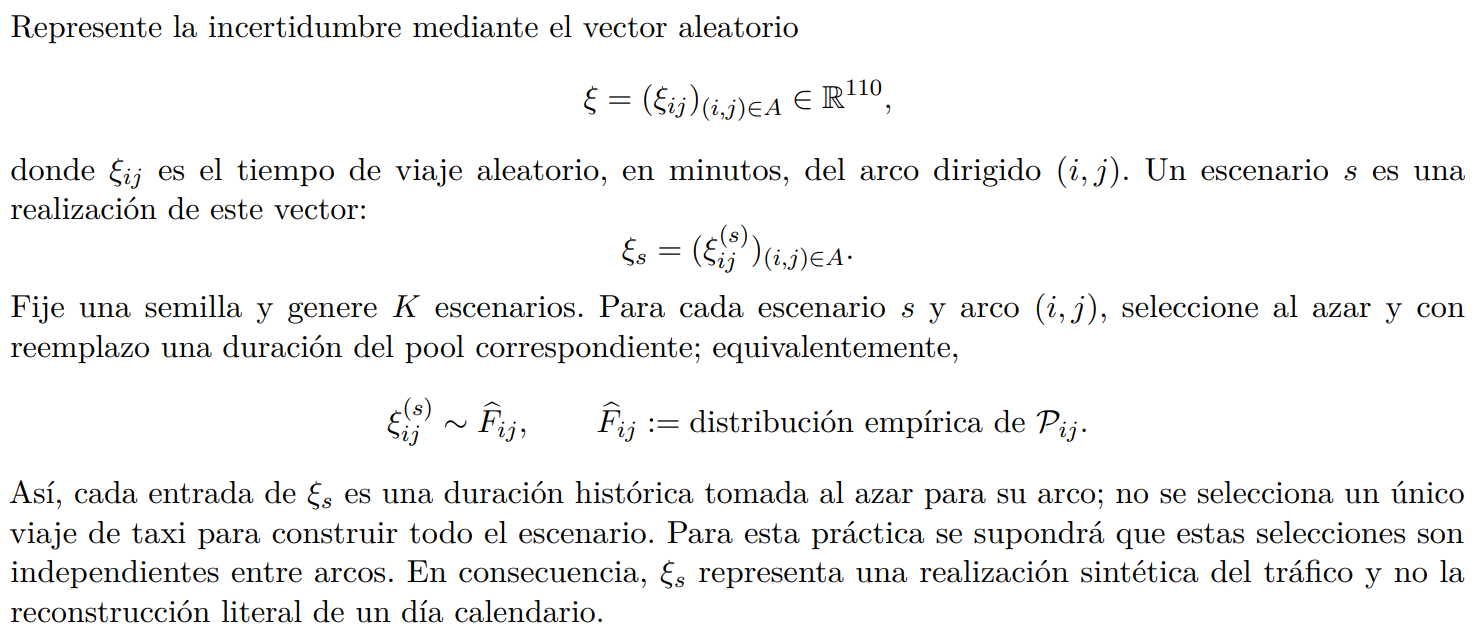

In [15]:
# Función auxiliar para generar los escenarios
def generar_escenarios(K, SEED=29):
  """
  Genera K escenarios para cada arco (i,j) simultáneamente con muestreo aleatorio
  con reemplazo.
  """
  # Revisar que K es un entero mayor a 0
  if not isinstance(K, int) or K <= 0:
    raise ValueError("K debe ser un entero mayor a 0")
  # Revisar que seed sea una semilla válida (el PRNG de polars acepta enteros)
  if not isinstance(SEED, int):
    raise ValueError("SEED debe ser un entero")

  # Data frame donde cada fila contiene una lista de longitud K [xi_ij^(1), ..., xi_ij^(K)]
  escenarios_df = pools.with_columns(
      pl.col("P_ij")
      .list.sample(n=K, with_replacement=True, seed=SEED) # muestreo aleatorio con reemplazo
      .alias("xi_ij_escenarios")
  )

  # Formato long para que se vean los escenarios explícitos (s = 1, ..., K)
  escenarios_long = (
      escenarios_df
      .select(["i", "j", "xi_ij_escenarios"])
      .explode("xi_ij_escenarios")
      .with_columns(
          (pl.int_range(0, pl.len()).over(["i", "j"]) + 1).alias("escenario_s")
      )
      .rename({"xi_ij_escenarios": "xi_s_ij"})
      .select(["escenario_s", pl.all().exclude("escenario_s")]) # Hacerla la primer columna
      .sort(["escenario_s", "i", "j"]) # ordenar por escenario y luego por arco
  )
  return escenarios_long

# Ejemplo
generar_escenarios(K=2, SEED=29)

escenario_s,i,j,xi_s_ij
i64,i64,i64,i64
1,0,1,14
1,0,2,16
1,0,3,31
1,0,4,13
1,0,5,12
…,…,…,…
2,10,5,12
2,10,6,6
2,10,7,10
